In [1]:
import sys
import os
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

Circuit for Classical Q vs. Flipping Picard:


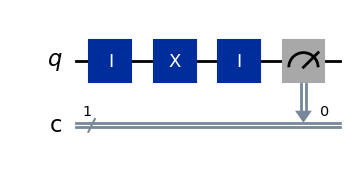

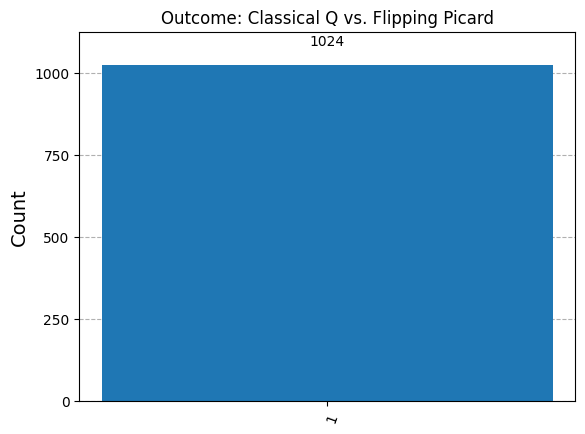

In [2]:
# Let's trace the circuit when Q plays classically (Identity) and Picard flips (X).
qc_classical = QuantumCircuit(1, 1)

# 1. Initial state |0>
# 2. Q's move: Identity (do nothing)
qc_classical.id(0)
# 3. Picard's move: Flip
qc_classical.x(0)
# 4. Q's move: Identity
qc_classical.id(0)
# 5. Measure
qc_classical.measure(0, 0)

print("Circuit for Classical Q vs. Flipping Picard:")
display(qc_classical.draw('mpl'))

# Simulate
backend = AerSimulator()
result = backend.run(qc_classical, shots=1024).result()
counts = result.get_counts()
plot_histogram(counts, title="Outcome: Classical Q vs. Flipping Picard")
# Result: Q loses (outcome is 0)


Circuit for Quantum Q vs. Flipping Picard:


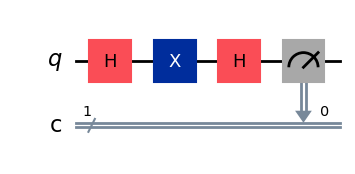

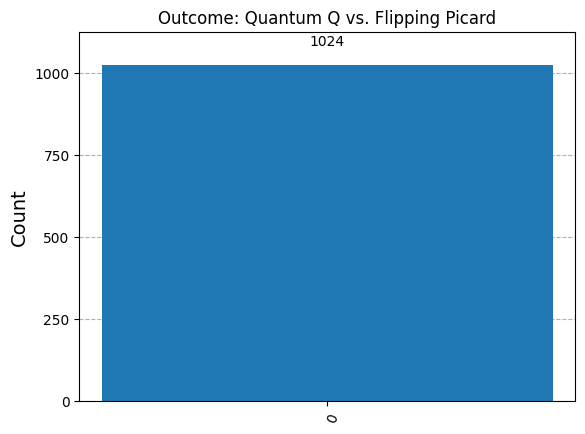

In [3]:
# Now, let's trace the circuit when Q plays with a Hadamard and Picard flips.
qc_quantum = QuantumCircuit(1, 1)

# 1. Initial state |0>
# 2. Q's move: Hadamard
qc_quantum.h(0)
# 3. Picard's move: Flip
qc_quantum.x(0)
# 4. Q's move: Hadamard
qc_quantum.h(0)
# 5. Measure
qc_quantum.measure(0, 0)

print("\nCircuit for Quantum Q vs. Flipping Picard:")
display(qc_quantum.draw('mpl'))

# Simulate
result = backend.run(qc_quantum, shots=1024).result()
counts = result.get_counts()
plot_histogram(counts, title="Outcome: Quantum Q vs. Flipping Picard")
# Result: Q wins! (outcome is 1)
# The H-X-H gate combination is equivalent to a Z gate, which flips |0> to |1> after the initial H.